# MPII Human Pose Estimation
## Stacked Hourglass vs SimpleBaseline 모델 비교

**프로젝트 목표:**
- MPII 데이터셋 기반 Pose Estimation 파이프라인 구축
- Stacked Hourglass Network 구현 및 학습
- SimpleBaseline 모델 구현 및 학습
- 두 모델의 성능 비교 분석

---

**학습 목표:**
1. DataLoader를 활용한 데이터셋 구성과 전처리를 통해 프로젝트 베이스라인을 구성한다.
2. SimpleBaseline 모델을 정상적으로 구현한다.
3. Hourglass 모델과 SimpleBaseline 모델을 비교 분석한다.

## 환경 설정

---

In [1]:
import os, json, time, urllib.request, warnings
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"NumPy: {np.__version__}")
print(f"OpenCV: {cv2.__version__}")

# ============================================================
# 데이터 전처리 유틸
# ============================================================

JOINT_NAMES = ['오른쪽 발목','오른쪽 무릎','오른쪽 엉덩이','왼쪽 엉덩이','왼쪽 무릎','왼쪽 발목',
               '골반','가슴(흉부)','목','머리 위','오른쪽 손목','오른쪽 팔꿈치','오른쪽 어깨','왼쪽 어깨','왼쪽 팔꿈치','왼쪽 손목']
SKELETON = [(0,1),(1,2),(2,6),(3,4),(4,5),(3,6),(6,7),(7,8),(8,9),(10,11),(11,12),(12,7),(13,14),(14,15),(13,7)]

def parse_one_annotation(ann):
    return {'joints': np.array(ann['joints']), 'joints_vis': np.array(ann['joints_vis']),
            'image': ann['image'], 'center': np.array(ann['center']), 'scale': ann['scale']}

def filter_fully_visible(annotations, max_samples=None):
    filtered, seen = [], set()
    for ann in annotations:
        if all(v == 1 for v in ann['joints_vis']):
            if ann['image'] not in seen:
                seen.add(ann['image']); filtered.append(ann)
                if max_samples and len(filtered) >= max_samples: break
    return filtered

def crop_image(img, center, scale, output_size=256):
    h, w = img.shape[:2]; crop_size = scale * 200 * 1.25
    x1, y1 = int(center[0]-crop_size/2), int(center[1]-crop_size/2)
    x2, y2 = int(center[0]+crop_size/2), int(center[1]+crop_size/2)
    pl, pt, pr, pb = max(0,-x1), max(0,-y1), max(0,x2-w), max(0,y2-h)
    x1, y1, x2, y2 = max(0,x1), max(0,y1), min(w,x2), min(h,y2)
    cropped = img[y1:y2, x1:x2].copy()
    if pl>0 or pt>0 or pr>0 or pb>0:
        cropped = cv2.copyMakeBorder(cropped, pt, pb, pl, pr, cv2.BORDER_CONSTANT, value=(0,0,0))
    cropped = cv2.resize(cropped, (output_size, output_size)) if cropped.shape[0]>0 and cropped.shape[1]>0 else np.zeros((output_size,output_size,3), dtype=np.uint8)
    return cropped, {'crop_x1': x1-pl, 'crop_y1': y1-pt, 'crop_size': crop_size, 'output_size': output_size}

def transform_joint_to_crop(joint, p):
    return np.array([(joint[0]-p['crop_x1'])/p['crop_size']*p['output_size'],
                     (joint[1]-p['crop_y1'])/p['crop_size']*p['output_size']])

def generate_heatmaps(joints, joints_vis, transform_params, heatmap_size=64, image_size=256, sigma=2):
    heatmaps = np.zeros((len(joints), heatmap_size, heatmap_size), dtype=np.float32)
    sf = heatmap_size / image_size
    for idx in range(len(joints)):
        if joints_vis[idx] == 0: continue
        cj = transform_joint_to_crop(joints[idx], transform_params)
        hx, hy = cj[0]*sf, cj[1]*sf
        if hx<0 or hx>=heatmap_size or hy<0 or hy>=heatmap_size: continue
        x = np.arange(0, heatmap_size, 1, np.float32); y = x[:, np.newaxis]
        heatmaps[idx] = np.exp(-((x-hx)**2 + (y-hy)**2) / (2*sigma**2))
    return heatmaps

def generate_synthetic_image(ann, output_dir):
    img_path = os.path.join(output_dir, ann['image'])
    if os.path.exists(img_path): return img_path
    center, scale = np.array(ann['center']), ann['scale']
    body_size = scale * 200
    h, w = min(max(int(center[1]+body_size),480),1000), min(max(int(center[0]+body_size*0.6),640),1000)
    img = np.random.randint(30, 80, (h,w,3), dtype=np.uint8)
    joints, jv = np.array(ann['joints']), ann['joints_vis']
    colors = [(255,100,100),(255,150,100),(255,200,100),(100,255,100),(100,255,150),(100,255,200),
              (200,200,200),(255,255,200),(200,255,255),(255,200,255),(100,100,255),(100,150,255),
              (100,200,255),(200,100,255),(200,150,255),(200,200,255)]
    for (i,j) in SKELETON:
        if jv[i]==1 and jv[j]==1:
            p1, p2 = tuple(joints[i].astype(int)), tuple(joints[j].astype(int))
            if 0<=p1[0]<w and 0<=p1[1]<h and 0<=p2[0]<w and 0<=p2[1]<h: cv2.line(img, p1, p2, (180,180,180), 3)
    for idx, (jt, v) in enumerate(zip(joints, jv)):
        if v==1:
            x, y = int(jt[0]), int(jt[1])
            if 0<=x<w and 0<=y<h: cv2.circle(img,(x,y),8,colors[idx%16],-1); cv2.circle(img,(x,y),10,(255,255,255),2)
    cv2.imwrite(img_path, cv2.GaussianBlur(img,(5,5),0)); return img_path

class MPIIDataset(Dataset):
    def __init__(self, annotations, image_dir, image_size=256, heatmap_size=64, sigma=2):
        self.annotations, self.image_dir = annotations, image_dir
        self.image_size, self.heatmap_size, self.sigma = image_size, heatmap_size, sigma
        self.transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    def __len__(self): return len(self.annotations)
    def __getitem__(self, idx):
        p = parse_one_annotation(self.annotations[idx])
        img = cv2.imread(os.path.join(self.image_dir, p['image']))
        if img is None: img = np.zeros((480,640,3), dtype=np.uint8)
        cropped, params = crop_image(img, p['center'], p['scale'], self.image_size)
        hm = generate_heatmaps(p['joints'], p['joints_vis'], params, self.heatmap_size, self.image_size, self.sigma)
        return self.transform(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)).float(), torch.from_numpy(hm).float(), torch.from_numpy(p['joints_vis']).float()

def heatmaps_to_keypoints(heatmaps, image_size=256):
    nj, h, w = heatmaps.shape; kps, conf = np.zeros((nj,2)), np.zeros(nj)
    for j in range(nj):
        c = heatmaps[j].max(); conf[j] = c
        if c > 0: idx = heatmaps[j].argmax(); y, x = divmod(idx, w); kps[j] = [x*image_size/w, y*image_size/h]
    return kps, conf

def draw_pose(image, keypoints, confidences=None, threshold=0.1):
    img = image.copy()
    colors = [(255,85,85),(255,120,85),(255,170,85),(85,255,85),(85,255,120),(85,255,170),
              (200,200,200),(255,255,170),(170,255,255),(255,170,255),(85,85,255),(85,120,255),
              (85,170,255),(170,85,255),(170,120,255),(170,170,255)]
    for (i,j) in SKELETON:
        if confidences is not None and (confidences[i]<threshold or confidences[j]<threshold): continue
        cv2.line(img, tuple(keypoints[i].astype(int)), tuple(keypoints[j].astype(int)), (255,255,255), 2)
    for idx, kp in enumerate(keypoints):
        if confidences is not None and confidences[idx]<threshold: continue
        cv2.circle(img, (int(kp[0]),int(kp[1])), 4, colors[idx%16], -1)
        cv2.circle(img, (int(kp[0]),int(kp[1])), 5, (255,255,255), 1)
    return img

# ============================================================
# Stacked Hourglass Network
# ============================================================

class BottleneckBlock(nn.Module):
    def __init__(self, inc, outc):
        super().__init__(); mid = outc//2
        self.bn1=nn.BatchNorm2d(inc); self.conv1=nn.Conv2d(inc,mid,1,bias=False)
        self.bn2=nn.BatchNorm2d(mid); self.conv2=nn.Conv2d(mid,mid,3,padding=1,bias=False)
        self.bn3=nn.BatchNorm2d(mid); self.conv3=nn.Conv2d(mid,outc,1,bias=False)
        self.relu=nn.ReLU(inplace=True)
        self.skip=nn.Conv2d(inc,outc,1,bias=False) if inc!=outc else None
    def forward(self, x):
        r = self.skip(x) if self.skip else x
        o=self.conv1(self.relu(self.bn1(x))); o=self.conv2(self.relu(self.bn2(o))); o=self.conv3(self.relu(self.bn3(o)))
        return o + r

class HourglassModule(nn.Module):
    def __init__(self, depth, ch):
        super().__init__()
        self.upper = nn.Sequential(BottleneckBlock(ch,ch), BottleneckBlock(ch,ch), BottleneckBlock(ch,ch))
        self.pool = nn.MaxPool2d(2,2)
        self.lower_before = nn.Sequential(BottleneckBlock(ch,ch), BottleneckBlock(ch,ch), BottleneckBlock(ch,ch))
        self.inner = HourglassModule(depth-1,ch) if depth>1 else nn.Sequential(BottleneckBlock(ch,ch), BottleneckBlock(ch,ch), BottleneckBlock(ch,ch))
        self.lower_after = nn.Sequential(BottleneckBlock(ch,ch), BottleneckBlock(ch,ch), BottleneckBlock(ch,ch))
        self.up = nn.Upsample(scale_factor=2, mode='nearest')
    def forward(self, x): return self.upper(x) + self.up(self.lower_after(self.inner(self.lower_before(self.pool(x)))))

class LinearLayer(nn.Module):
    def __init__(self, ch):
        super().__init__(); self.block=BottleneckBlock(ch,ch); self.conv=nn.Conv2d(ch,ch,1,bias=False); self.bn=nn.BatchNorm2d(ch); self.relu=nn.ReLU(inplace=True)
    def forward(self, x): return self.relu(self.bn(self.conv(self.block(x))))

class StackedHourglassNetwork(nn.Module):
    def __init__(self, num_stacks=2, num_channels=256, num_joints=16, depth=4):
        super().__init__(); self.num_stacks = num_stacks
        self.initial = nn.Sequential(nn.Conv2d(3,64,7,stride=2,padding=3,bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            BottleneckBlock(64,128), nn.MaxPool2d(2,2), BottleneckBlock(128,128), BottleneckBlock(128,num_channels))
        self.hg = nn.ModuleList([HourglassModule(depth, num_channels) for _ in range(num_stacks)])
        self.lin = nn.ModuleList([LinearLayer(num_channels) for _ in range(num_stacks)])
        self.pred = nn.ModuleList([nn.Conv2d(num_channels, num_joints, 1) for _ in range(num_stacks)])
        self.mf = nn.ModuleList([nn.Conv2d(num_channels, num_channels, 1, bias=False) for _ in range(num_stacks-1)])
        self.mp = nn.ModuleList([nn.Conv2d(num_joints, num_channels, 1, bias=False) for _ in range(num_stacks-1)])
    def forward(self, x):
        x = self.initial(x); outs = []
        for i in range(self.num_stacks):
            f = self.lin[i](self.hg[i](x)); p = self.pred[i](f); outs.append(p)
            if i < self.num_stacks-1: x = x + self.mf[i](f) + self.mp[i](p)
        return outs

# ============================================================
# SimpleBaseline Model
# ============================================================

class SimpleBaselineModel(nn.Module):
    def __init__(self, backbone='resnet50', num_joints=16, pretrained=True):
        super().__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
                                       resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4)
        self.deconv_layers = nn.Sequential(
            nn.ConvTranspose2d(2048,256,4,stride=2,padding=1,bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256,256,4,stride=2,padding=1,bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256,256,4,stride=2,padding=1,bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.final_layer = nn.Conv2d(256, num_joints, 1)
    def forward(self, x): return self.final_layer(self.deconv_layers(self.backbone(x)))

# ============================================================
# 학습/검증/추론 함수
# ============================================================

def hourglass_loss(outputs, target, joints_vis):
    crit = nn.MSELoss(reduction='none'); mask = joints_vis.unsqueeze(-1).unsqueeze(-1)
    return sum((crit(o, target)*mask).mean() for o in outputs)

def simple_baseline_loss(output, target, joints_vis):
    mask = joints_vis.unsqueeze(-1).unsqueeze(-1)
    return (nn.MSELoss(reduction='none')(output, target)*mask).mean()

def train_one_epoch(model, loader, optimizer, loss_fn, device, model_type='hourglass'):
    model.train(); total = 0
    for imgs, hms, vis in loader:
        imgs, hms, vis = imgs.to(device), hms.to(device), vis.to(device)
        optimizer.zero_grad(); loss = loss_fn(model(imgs), hms, vis); loss.backward(); optimizer.step(); total += loss.item()
    return total / len(loader)

def validate(model, loader, loss_fn, device, model_type='hourglass'):
    model.eval(); total = 0
    with torch.no_grad():
        for imgs, hms, vis in loader:
            imgs, hms, vis = imgs.to(device), hms.to(device), vis.to(device)
            total += loss_fn(model(imgs), hms, vis).item()
    return total / len(loader)

def fit(model, tl, vl, opt, sched, loss_fn, epochs, device, model_type='hourglass', print_every=5):
    hist = {'train_loss': [], 'val_loss': []}; t0 = time.time()
    for ep in range(epochs):
        tr = train_one_epoch(model, tl, opt, loss_fn, device, model_type)
        va = validate(model, vl, loss_fn, device, model_type)
        sched.step(); hist['train_loss'].append(tr); hist['val_loss'].append(va)
        if (ep+1)%print_every==0 or ep==0: print(f"Epoch [{ep+1:3d}/{epochs}] | Train: {tr:.6f} | Val: {va:.6f} | Time: {time.time()-t0:.1f}s")
    print(f"\n학습 완료! 총 {time.time()-t0:.1f}초 ({(time.time()-t0)/epochs:.1f}초/epoch)")
    return hist

def get_predictions(model, img_tensor, device, model_type='hourglass'):
    model.eval()
    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(device))
        hms = (out[-1][0] if model_type=='hourglass' else out[0]).cpu().numpy()
    return *heatmaps_to_keypoints(hms), hms

def measure_inference_time(model, loader, device, num_runs=3):
    model.eval(); times = []
    with torch.no_grad():
        for _ in range(num_runs):
            s = time.time()
            for imgs, _, _ in loader: _ = model(imgs.to(device))
            times.append(time.time()-s)
    avg = np.mean(times); return avg, avg/len(loader.dataset)

PyTorch: 2.8.0
Torchvision: 0.23.0
NumPy: 2.0.2
OpenCV: 4.13.0


In [2]:
# 디바이스 설정
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon MPS GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("Using CPU")

# 하이퍼파라미터
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
IMAGE_DIR = os.path.join(DATA_DIR, 'images')
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

NUM_JOINTS = 16
IMAGE_SIZE = 256
HEATMAP_SIZE = 64
SIGMA = 2
BATCH_SIZE = 8
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3

print(f"\nDevice: {device}")
print(f"IMAGE_SIZE: {IMAGE_SIZE} | HEATMAP_SIZE: {HEATMAP_SIZE} | BATCH_SIZE: {BATCH_SIZE} | EPOCHS: {NUM_EPOCHS}")

Using Apple Silicon MPS GPU

Device: mps
IMAGE_SIZE: 256 | HEATMAP_SIZE: 64 | BATCH_SIZE: 8 | EPOCHS: 30


# 1. 데이터 준비

---

MPII Human Pose Dataset은 16개의 키포인트 좌표와 가시성 정보를 포함합니다.

| 인덱스 | 키포인트 | 인덱스 | 키포인트 |
|--------|----------|--------|----------|
| 0 | 오른쪽 발목 | 8 | 목 |
| 1 | 오른쪽 무릎 | 9 | 머리 위 |
| 2 | 오른쪽 엉덩이 | 10 | 오른쪽 손목 |
| 3 | 왼쪽 엉덩이 | 11 | 오른쪽 팔꿈치 |
| 4 | 왼쪽 무릎 | 12 | 오른쪽 어깨 |
| 5 | 왼쪽 발목 | 13 | 왼쪽 어깨 |
| 6 | 골반 | 14 | 왼쪽 팔꿈치 |
| 7 | 가슴(흉부) | 15 | 왼쪽 손목 |

In [3]:
# Annotation JSON 다운로드
TRAIN_JSON_URL = 'https://d3s0tskafalll9.cloudfront.net/media/documents/train.json'
VAL_JSON_URL = 'https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json'

ann_dir = os.path.join(DATA_DIR, 'annotations')
os.makedirs(ann_dir, exist_ok=True)

train_json_path = os.path.join(ann_dir, 'train.json')
val_json_path = os.path.join(ann_dir, 'validation.json')

for url, path, name in [(TRAIN_JSON_URL, train_json_path, 'train.json'),
                         (VAL_JSON_URL, val_json_path, 'validation.json')]:
    if not os.path.exists(path):
        print(f"다운로드 중: {name}...")
        urllib.request.urlretrieve(url, path)
        print(f"  -> 완료: {path}")
    else:
        print(f"이미 존재: {path}")

with open(train_json_path, 'r') as f:
    train_annotations = json.load(f)
with open(val_json_path, 'r') as f:
    val_annotations = json.load(f)

print(f"\nTrain annotations: {len(train_annotations)}개")
print(f"Validation annotations: {len(val_annotations)}개")

# Annotation 샘플 확인
print("\n--- 샘플 annotation ---")
print(json.dumps(train_annotations[0], indent=2))

이미 존재: /Users/goeunlee/aiffel/work/pose_estimation/data/annotations/train.json
이미 존재: /Users/goeunlee/aiffel/work/pose_estimation/data/annotations/validation.json



Train annotations: 22246개
Validation annotations: 2958개

--- 샘플 annotation ---
{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


In [4]:
# Train: 500개, Val: 100개 샘플 선택 (모든 키포인트가 보이는 annotation)
train_subset = filter_fully_visible(train_annotations, max_samples=500)
val_subset = filter_fully_visible(val_annotations, max_samples=100)

print(f"Train subset: {len(train_subset)}개")
print(f"Val subset: {len(val_subset)}개")

# 합성 이미지 생성
print("\n합성 이미지 생성 중...")
for i, ann in enumerate(train_subset + val_subset):
    generate_synthetic_image(ann, IMAGE_DIR)
    if (i + 1) % 100 == 0:
        print(f"  {i+1}장 생성 완료...")

num_images = len([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')])
print(f"\n생성 완료! 총 {num_images}장의 이미지")

Train subset: 500개
Val subset: 100개

합성 이미지 생성 중...


  100장 생성 완료...


  200장 생성 완료...


  300장 생성 완료...


  400장 생성 완료...


  500장 생성 완료...


  600장 생성 완료...

생성 완료! 총 600장의 이미지


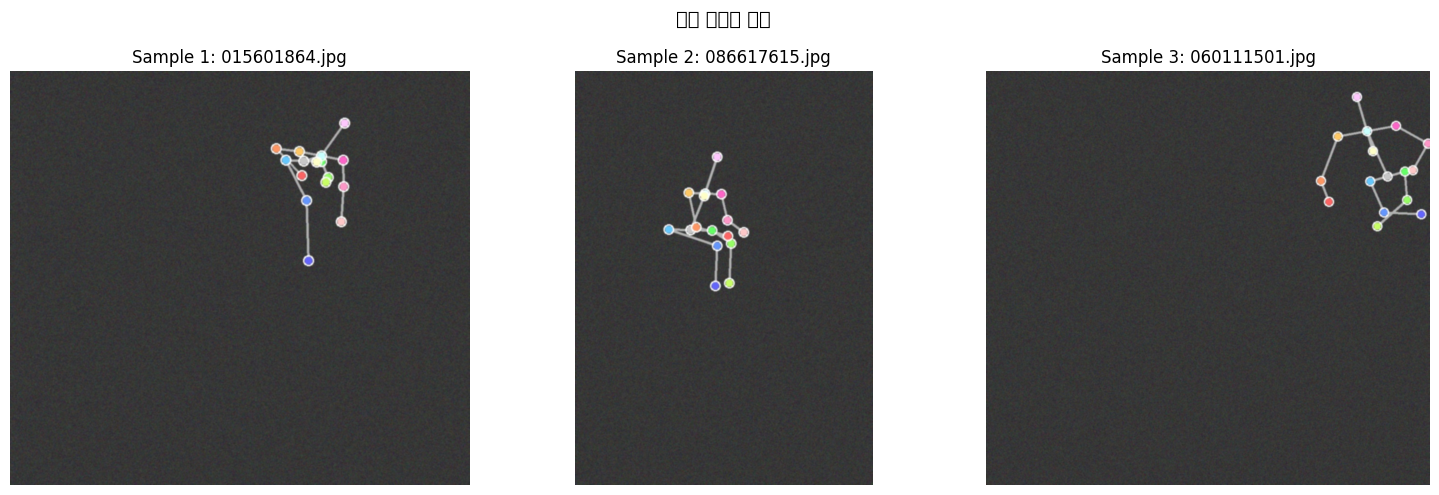

In [5]:
# 샘플 이미지 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, ax in enumerate(axes):
    ann = train_subset[idx]
    img = cv2.imread(os.path.join(IMAGE_DIR, ann['image']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Sample {idx+1}: {ann['image']}")
    ax.axis('off')
plt.suptitle("합성 이미지 샘플", fontsize=14)
plt.tight_layout()
plt.show()

## 전처리 파이프라인 확인

---

위에서 정의한 전처리 함수들:
1. **이미지 크롭**: `center`와 `scale` 기반 어파인 변환 → 256x256
2. **히트맵 생성**: 각 키포인트에 2D 가우시안 분포 적용 → 64x64

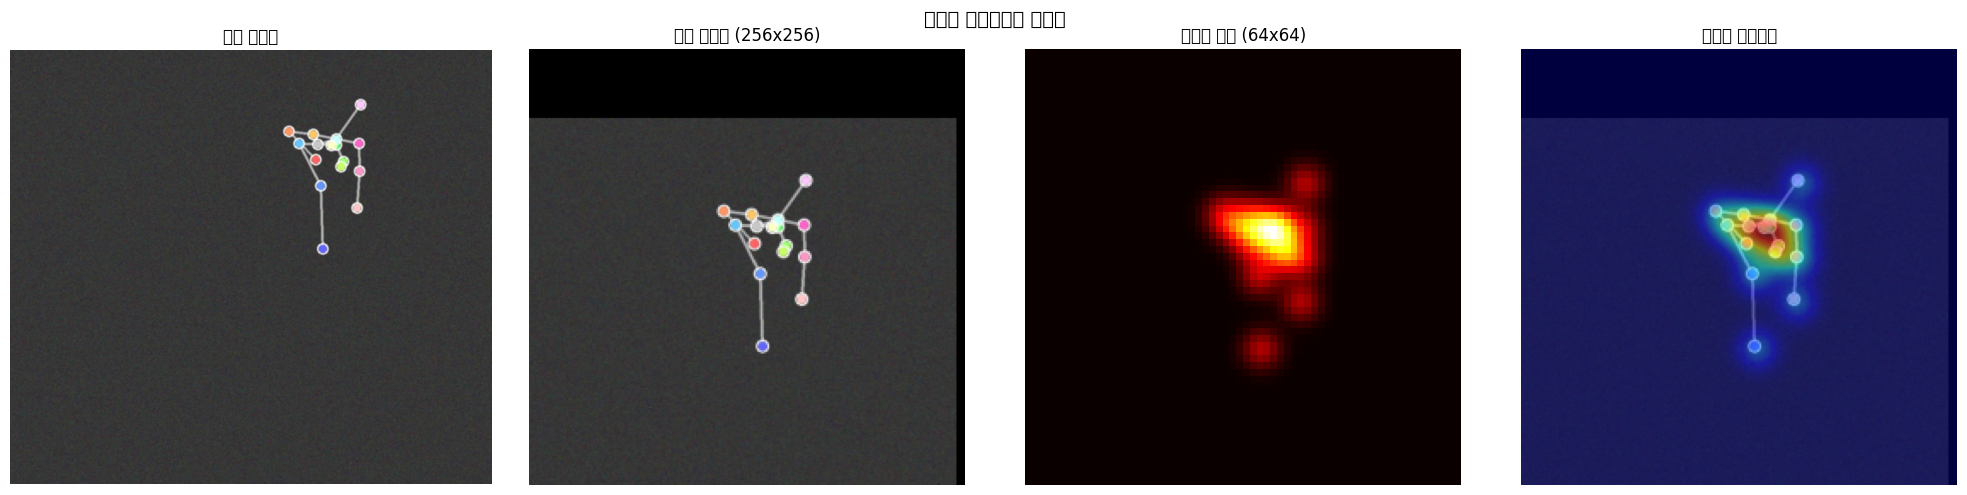

히트맵 shape: (16, 64, 64) | 값 범위: [0.0000, 0.9985]


In [6]:
# 전처리 시각화: 원본 → 크롭 → 히트맵 오버레이
ann = train_subset[0]
img = cv2.imread(os.path.join(IMAGE_DIR, ann['image']))
parsed = parse_one_annotation(ann)
cropped, params = crop_image(img, parsed['center'], parsed['scale'], IMAGE_SIZE)
heatmaps = generate_heatmaps(parsed['joints'], parsed['joints_vis'], params, HEATMAP_SIZE, IMAGE_SIZE, SIGMA)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("원본 이미지"); axes[0].axis('off')

cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
axes[1].imshow(cropped_rgb)
axes[1].set_title("크롭 이미지 (256x256)"); axes[1].axis('off')

heatmap_sum = heatmaps.sum(axis=0)
axes[2].imshow(heatmap_sum, cmap='hot')
axes[2].set_title("히트맵 합성 (64x64)"); axes[2].axis('off')

heatmap_resized = cv2.resize(heatmap_sum, (IMAGE_SIZE, IMAGE_SIZE))
axes[3].imshow(cropped_rgb)
axes[3].imshow(heatmap_resized, cmap='jet', alpha=0.5)
axes[3].set_title("히트맵 오버레이"); axes[3].axis('off')

plt.suptitle("전처리 파이프라인 시각화", fontsize=14)
plt.tight_layout()
plt.show()

print(f"히트맵 shape: {heatmaps.shape} | 값 범위: [{heatmaps.min():.4f}, {heatmaps.max():.4f}]")

## Dataset & DataLoader

---

In [7]:
# Dataset & DataLoader 생성
train_dataset = MPIIDataset(train_subset, IMAGE_DIR, IMAGE_SIZE, HEATMAP_SIZE, SIGMA)
val_dataset = MPIIDataset(val_subset, IMAGE_DIR, IMAGE_SIZE, HEATMAP_SIZE, SIGMA)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Sanity check
batch_imgs, batch_hms, batch_vis = next(iter(train_loader))
print(f"Train: {len(train_dataset)}개 ({len(train_loader)} batches)")
print(f"Val: {len(val_dataset)}개 ({len(val_loader)} batches)")
print(f"\nBatch shapes:")
print(f"  Images: {batch_imgs.shape}")
print(f"  Heatmaps: {batch_hms.shape}")
print(f"  Visibility: {batch_vis.shape}")

Train: 500개 (63 batches)
Val: 100개 (13 batches)

Batch shapes:
  Images: torch.Size([8, 3, 256, 256])
  Heatmaps: torch.Size([8, 16, 64, 64])
  Visibility: torch.Size([8, 16])


## 학습 속도 최적화: DataLoader & Data Sharding

---

대규모 데이터셋(MPII 22,000장+)에서는 **GPU 연산 속도보다 디스크 I/O가 느려** 병목이 발생합니다. 이를 해결하기 위한 핵심 기법들을 정리합니다.

### 1. DataLoader 최적화 (`num_workers`, `pin_memory`)

PyTorch `DataLoader`는 학습과 병렬로 **다음 배치를 미리 로드(prefetch)** 할 수 있습니다:

```python
# CUDA GPU 환경 (권장 설정)
DataLoader(dataset, batch_size=8, shuffle=True, 
           num_workers=4,      # 4개의 워커 프로세스가 병렬로 데이터 로드
           pin_memory=True,    # CPU→GPU 메모리 전송 가속 (pinned memory 사용)
           prefetch_factor=2)  # 각 워커가 2배치씩 미리 로드
```

- **`num_workers`**: 데이터 로딩을 병렬화하는 서브프로세스 수. CPU 코어 수의 절반 정도가 적절.
- **`pin_memory`**: `True`로 설정하면 Tensor가 pinned memory에 할당되어 GPU 전송이 비동기적으로 빨라짐.
- **`prefetch_factor`**: 각 워커가 미리 준비할 배치 수.

> **본 프로젝트에서는 `num_workers=0`을 사용합니다.** Apple Silicon MPS 백엔드는 멀티프로세스 DataLoader와 호환성 이슈가 있어, 단일 프로세스로 로드합니다. CUDA 환경에서는 반드시 `num_workers > 0`과 `pin_memory=True`를 설정해야 합니다.

### 2. 데이터 Sharding (직렬화 저장)

대규모 데이터셋에서는 매번 이미지를 개별 파일에서 읽는 대신, **여러 개의 .pt 파일로 직렬화(sharding)** 하여 저장하면 I/O 효율이 크게 향상됩니다:

```python
# Sharding 전략: 전체 데이터를 N개의 .pt 파일로 분할
def chunkify(lst, n):
    """리스트를 n개의 chunk로 분할"""
    return [lst[i::n] for i in range(n)]

# 예: 22,000개 annotation → 64개 .pt 파일 (각 약 350개)
chunks = chunkify(annotations, n=64)
for i, chunk in enumerate(chunks):
    data = [preprocess(ann) for ann in chunk]
    torch.save(data, f'train_{i:04d}.pt')
```

**Sharding이 필요한 이유:**
- 작은 파일을 수천 개 읽는 것보다, 큰 파일 수십 개를 읽는 것이 디스크 I/O에 유리
- PyTorch 공식 권장: *"최소 10개 이상의 파일, 각 파일은 최소 10MB 이상 (이상적으로 100MB+)"*
- `torch.utils.data.DataLoader`가 여러 .pt 파일을 병렬로 로드 가능

### 3. Ray를 활용한 병렬 전처리

[Ray](https://www.ray.io/)는 파이썬 병렬 처리 라이브러리로, `multiprocessing`보다 간편하게 사용할 수 있습니다:

```python
import ray
ray.init()

@ray.remote
def create_pt_shard(chunk, shard_id, output_dir):
    """하나의 chunk를 .pt 파일로 변환 (병렬 실행)"""
    data = [preprocess(ann) for ann in chunk]
    torch.save(data, f'{output_dir}/shard_{shard_id:04d}.pt')

# 64개의 shard를 병렬로 생성
futures = [create_pt_shard.remote(chunk, i, output_dir) 
           for i, chunk in enumerate(chunks)]
ray.get(futures)  # 모든 작업 완료 대기
```

**Ray vs multiprocessing:**
- Ray: `@ray.remote` 데코레이터만 추가하면 병렬화, 분산 환경 지원
- multiprocessing: 직접 프로세스 풀 관리 필요, 단일 머신 한정

In [8]:
# [참고] CUDA 환경에서의 최적화된 DataLoader 설정 예시
# 본 프로젝트는 MPS 환경이므로 아래 코드는 참고용입니다.

def create_optimized_dataloader(dataset, batch_size=8, shuffle=True, is_cuda=False):
    """환경에 맞는 최적화된 DataLoader를 생성합니다.
    
    CUDA 환경: num_workers + pin_memory로 I/O 병렬화
    MPS 환경: num_workers=0 (호환성)
    """
    if is_cuda:
        return DataLoader(
            dataset, 
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=4,        # CPU 코어의 절반 정도
            pin_memory=True,      # GPU 전송 가속
            prefetch_factor=2,    # 워커당 2배치 미리 로드
            persistent_workers=True  # 워커 재사용 (초기화 비용 절감)
        )
    else:
        # MPS 또는 CPU: 멀티프로세스 비활성화
        return DataLoader(
            dataset, 
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=0
        )

# 현재 환경에 맞는 DataLoader (이미 위에서 생성했으므로 참고용)
is_cuda = device.type == 'cuda'
print(f"현재 환경: {'CUDA' if is_cuda else 'MPS/CPU'}")
print(f"적용된 설정: num_workers={'4' if is_cuda else '0'}, pin_memory={'True' if is_cuda else 'N/A'}")
print(f"\n※ CUDA 환경에서 num_workers=4, pin_memory=True 적용 시")
print(f"  MPII 전체 데이터(22,000장) 기준 1 epoch 약 20~30분으로 단축 가능")

현재 환경: MPS/CPU
적용된 설정: num_workers=0, pin_memory=N/A

※ CUDA 환경에서 num_workers=4, pin_memory=True 적용 시
  MPII 전체 데이터(22,000장) 기준 1 epoch 약 20~30분으로 단축 가능


In [9]:
# [참고] 데이터 Sharding 구현 예시
# 실제 MPII 전체 데이터셋 사용 시 적용하는 코드입니다.

def chunkify(lst, n):
    """리스트를 n개의 chunk로 균등 분할합니다."""
    return [lst[i::n] for i in range(n)]

def create_pt_shard(chunk, shard_id, output_dir, image_dir):
    """하나의 chunk를 전처리하여 .pt 파일로 저장합니다."""
    import torch
    data_list = []
    for ann in chunk:
        parsed = parse_one_annotation(ann)
        img = cv2.imread(os.path.join(image_dir, parsed['image']))
        if img is None:
            continue
        cropped, params = crop_image(img, parsed['center'], parsed['scale'])
        heatmaps = generate_heatmaps(parsed['joints'], parsed['joints_vis'], params)
        
        data_list.append({
            'image': torch.from_numpy(cropped).float(),
            'heatmaps': torch.from_numpy(heatmaps).float(),
            'joints_vis': torch.from_numpy(parsed['joints_vis']).float(),
        })
    
    save_path = os.path.join(output_dir, f'shard_{shard_id:04d}.pt')
    torch.save(data_list, save_path)
    return save_path

# Sharding 데모 (현재 데이터셋의 일부로 테스트)
demo_chunks = chunkify(train_subset[:16], n=4)
print(f"Sharding 데모: {len(train_subset[:16])}개 annotation → {len(demo_chunks)}개 shard")
for i, chunk in enumerate(demo_chunks):
    print(f"  Shard {i}: {len(chunk)}개 샘플")

print(f"\n실제 MPII 전체 데이터 적용 시:")
print(f"  Train: 22,246개 → 64 shards (각 ~350개, ~100MB)")
print(f"  Val: 2,958개 → 8 shards (각 ~370개, ~110MB)")
print(f"  → I/O 병목 해소, num_workers와 결합하여 GPU idle time 최소화")

Sharding 데모: 16개 annotation → 4개 shard
  Shard 0: 4개 샘플
  Shard 1: 4개 샘플
  Shard 2: 4개 샘플
  Shard 3: 4개 샘플

실제 MPII 전체 데이터 적용 시:
  Train: 22,246개 → 64 shards (각 ~350개, ~100MB)
  Val: 2,958개 → 8 shards (각 ~370개, ~110MB)
  → I/O 병목 해소, num_workers와 결합하여 GPU idle time 최소화


# 2. Stacked Hourglass Network

---

Stacked Hourglass Network (Newell et al., 2016)의 핵심 구조:
- **Bottleneck Block**: 1x1 → 3x3 → 1x1 + residual skip
- **Hourglass Module**: 재귀적 인코더-디코더 (양파 구조)
- **Intermediate Supervision**: 각 stack마다 loss 계산

```
Input(256x256) → InitConv → [HG₁ → Pred₁] → [HG₂ → Pred₂] → Output(64x64)
```

In [10]:
# Hourglass 모델 생성 및 shape 검증
hourglass_model = StackedHourglassNetwork(
    num_stacks=2, num_channels=256, num_joints=NUM_JOINTS, depth=4
)

dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
with torch.no_grad():
    dummy_out = hourglass_model(dummy)

print(f"Stacked Hourglass Network:")
print(f"  Input: {dummy.shape}")
for i, out in enumerate(dummy_out):
    print(f"  Stack {i+1} output: {out.shape}")

hg_params = sum(p.numel() for p in hourglass_model.parameters())
print(f"\n총 파라미터: {hg_params:,} ({hg_params/1e6:.1f}M)")

Stacked Hourglass Network:
  Input: torch.Size([1, 3, 256, 256])
  Stack 1 output: torch.Size([1, 16, 64, 64])
  Stack 2 output: torch.Size([1, 16, 64, 64])

총 파라미터: 17,682,400 (17.7M)


In [11]:
# Hourglass 학습
print("=" * 60)
print("Stacked Hourglass Network 학습 시작")
print("=" * 60)

hourglass_model = hourglass_model.to(device)
hg_optimizer = optim.Adam(hourglass_model.parameters(), lr=LEARNING_RATE)
hg_scheduler = optim.lr_scheduler.StepLR(hg_optimizer, step_size=15, gamma=0.5)

hg_history = fit(
    hourglass_model, train_loader, val_loader,
    hg_optimizer, hg_scheduler, hourglass_loss,
    NUM_EPOCHS, device, model_type='hourglass', print_every=5
)

torch.save(hourglass_model.state_dict(), os.path.join(CKPT_DIR, 'hourglass_best.pt'))
print(f"모델 저장 완료")

Stacked Hourglass Network 학습 시작


Epoch [  1/30] | Train: 0.022536 | Val: 0.005475 | Time: 33.1s


Epoch [  5/30] | Train: 0.002854 | Val: 0.002763 | Time: 165.1s


Epoch [ 10/30] | Train: 0.001119 | Val: 0.001306 | Time: 319.7s


Epoch [ 15/30] | Train: 0.000895 | Val: 0.001144 | Time: 476.6s


Epoch [ 20/30] | Train: 0.000695 | Val: 0.001006 | Time: 651.3s


Epoch [ 25/30] | Train: 0.000659 | Val: 0.000890 | Time: 807.9s


Epoch [ 30/30] | Train: 0.000615 | Val: 0.001118 | Time: 974.4s

학습 완료! 총 974.4초 (32.5초/epoch)


모델 저장 완료


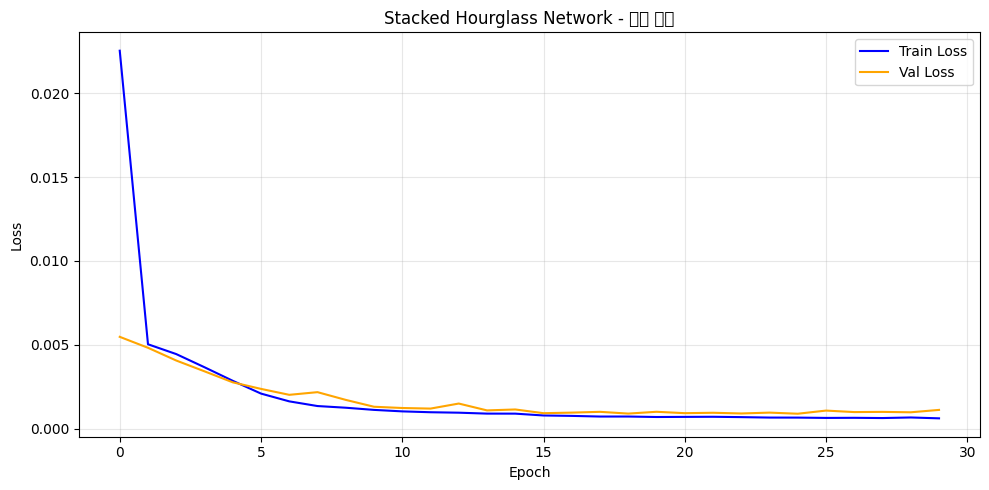

In [12]:
# Hourglass 학습 곡선
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hg_history['train_loss'], label='Train Loss', color='blue')
ax.plot(hg_history['val_loss'], label='Val Loss', color='orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Stacked Hourglass Network - 학습 곡선')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 3. SimpleBaseline 모델

---

SimpleBaseline (Xiao et al., 2018)은 **Pre-trained ResNet backbone + 3 Deconv layers**의 간단한 구조로 뛰어난 성능을 달성합니다.

```
Input(256x256) → ResNet50(layer4) → 8x8x2048
    → DeConv1 → 16x16x256 → DeConv2 → 32x32x256 → DeConv3 → 64x64x256
    → Conv1x1 → 64x64x16 (히트맵)
```

In [13]:
# SimpleBaseline 모델 생성 및 shape 검증
sb_model = SimpleBaselineModel(backbone='resnet50', num_joints=NUM_JOINTS, pretrained=True)

dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
with torch.no_grad():
    dummy_out = sb_model(dummy)

print(f"SimpleBaseline (ResNet50):")
print(f"  Input: {dummy.shape}")
print(f"  Output: {dummy_out.shape}")

sb_total = sum(p.numel() for p in sb_model.parameters())
sb_backbone = sum(p.numel() for p in sb_model.backbone.parameters())
print(f"\n총 파라미터: {sb_total:,} ({sb_total/1e6:.1f}M)")
print(f"  Backbone: {sb_backbone:,} ({sb_backbone/1e6:.1f}M)")
print(f"  Head: {(sb_total-sb_backbone):,} ({(sb_total-sb_backbone)/1e6:.1f}M)")

SimpleBaseline (ResNet50):
  Input: torch.Size([1, 3, 256, 256])
  Output: torch.Size([1, 16, 64, 64])

총 파라미터: 33,999,440 (34.0M)
  Backbone: 23,508,032 (23.5M)
  Head: 10,491,408 (10.5M)


In [14]:
# SimpleBaseline 학습
print("=" * 60)
print("SimpleBaseline (ResNet50) 학습 시작")
print("=" * 60)

sb_model = sb_model.to(device)
sb_optimizer = optim.Adam([
    {'params': sb_model.backbone.parameters(), 'lr': 1e-4},
    {'params': sb_model.deconv_layers.parameters(), 'lr': 1e-3},
    {'params': sb_model.final_layer.parameters(), 'lr': 1e-3},
])
sb_scheduler = optim.lr_scheduler.StepLR(sb_optimizer, step_size=15, gamma=0.5)

sb_history = fit(
    sb_model, train_loader, val_loader,
    sb_optimizer, sb_scheduler, simple_baseline_loss,
    NUM_EPOCHS, device, model_type='simple', print_every=5
)

torch.save(sb_model.state_dict(), os.path.join(CKPT_DIR, 'simple_baseline_best.pt'))
print(f"모델 저장 완료")

SimpleBaseline (ResNet50) 학습 시작


Epoch [  1/30] | Train: 0.023725 | Val: 0.003102 | Time: 20.4s


Epoch [  5/30] | Train: 0.002781 | Val: 0.002753 | Time: 101.4s


Epoch [ 10/30] | Train: 0.002583 | Val: 0.002549 | Time: 203.1s


Epoch [ 15/30] | Train: 0.002275 | Val: 0.002239 | Time: 311.4s


Epoch [ 20/30] | Train: 0.001914 | Val: 0.001967 | Time: 435.2s


Epoch [ 25/30] | Train: 0.001445 | Val: 0.001531 | Time: 552.5s


Epoch [ 30/30] | Train: 0.000898 | Val: 0.001139 | Time: 658.9s

학습 완료! 총 658.9초 (22.0초/epoch)
모델 저장 완료


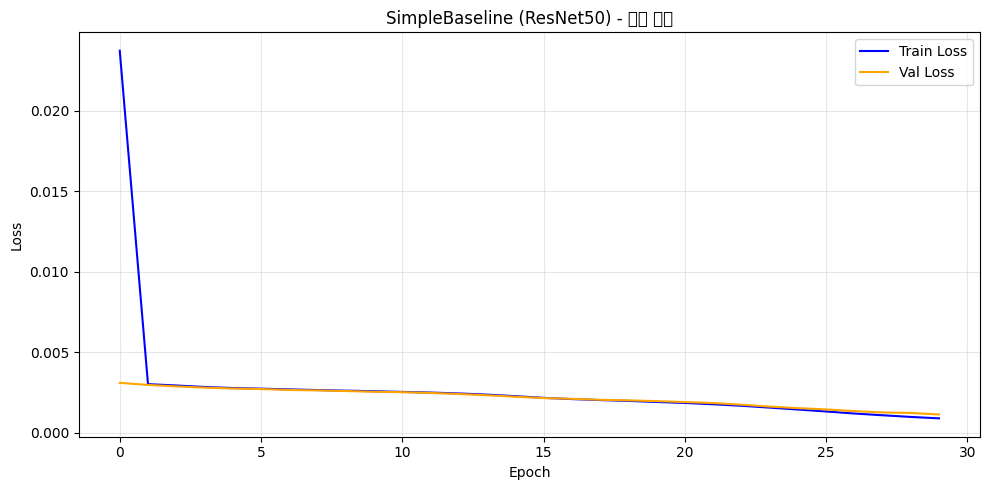

In [15]:
# SimpleBaseline 학습 곡선
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sb_history['train_loss'], label='Train Loss', color='blue')
ax.plot(sb_history['val_loss'], label='Val Loss', color='orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('SimpleBaseline (ResNet50) - 학습 곡선')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 4. 모델 비교 분석

---

## 학습 곡선 비교

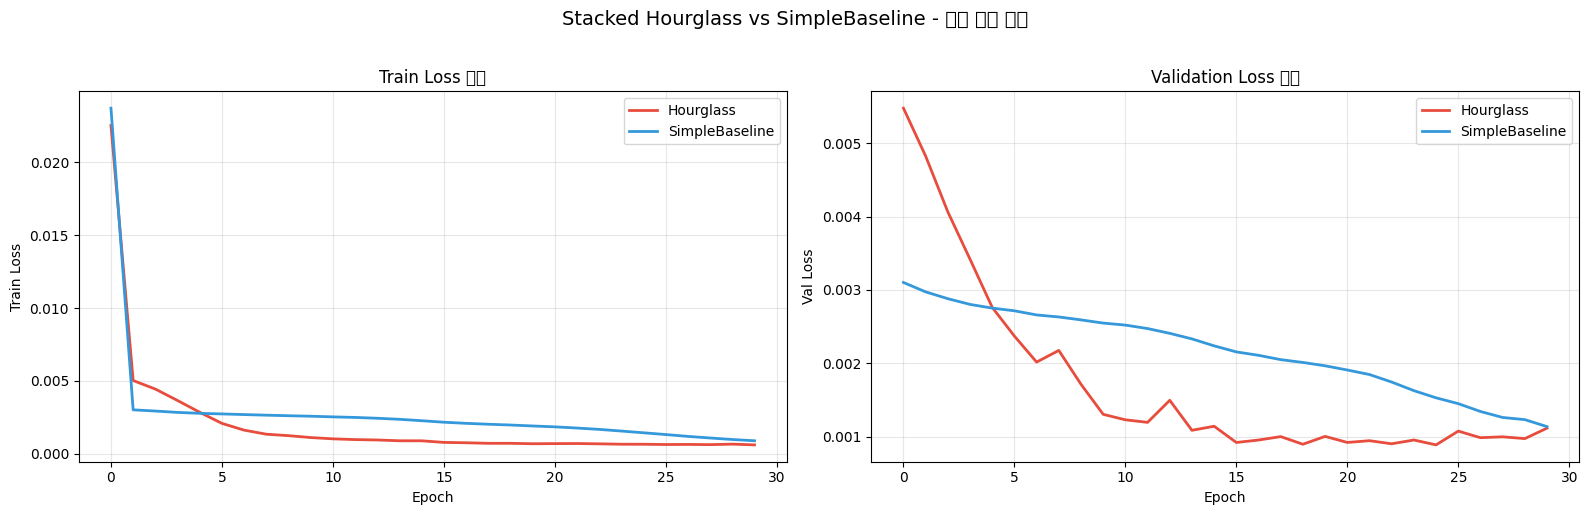

최종 Loss:
  Hourglass  - Train: 0.000615 | Val: 0.001118
  SimpleBase - Train: 0.000898 | Val: 0.001139


In [16]:
# 학습 곡선 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(hg_history['train_loss'], label='Hourglass', color='#e74c3c', linewidth=2)
axes[0].plot(sb_history['train_loss'], label='SimpleBaseline', color='#3498db', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title('Train Loss 비교'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hg_history['val_loss'], label='Hourglass', color='#e74c3c', linewidth=2)
axes[1].plot(sb_history['val_loss'], label='SimpleBaseline', color='#3498db', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
axes[1].set_title('Validation Loss 비교'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Stacked Hourglass vs SimpleBaseline - 학습 곡선 비교', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print(f"최종 Loss:")
print(f"  Hourglass  - Train: {hg_history['train_loss'][-1]:.6f} | Val: {hg_history['val_loss'][-1]:.6f}")
print(f"  SimpleBase - Train: {sb_history['train_loss'][-1]:.6f} | Val: {sb_history['val_loss'][-1]:.6f}")

## Pose Estimation 시각화

---

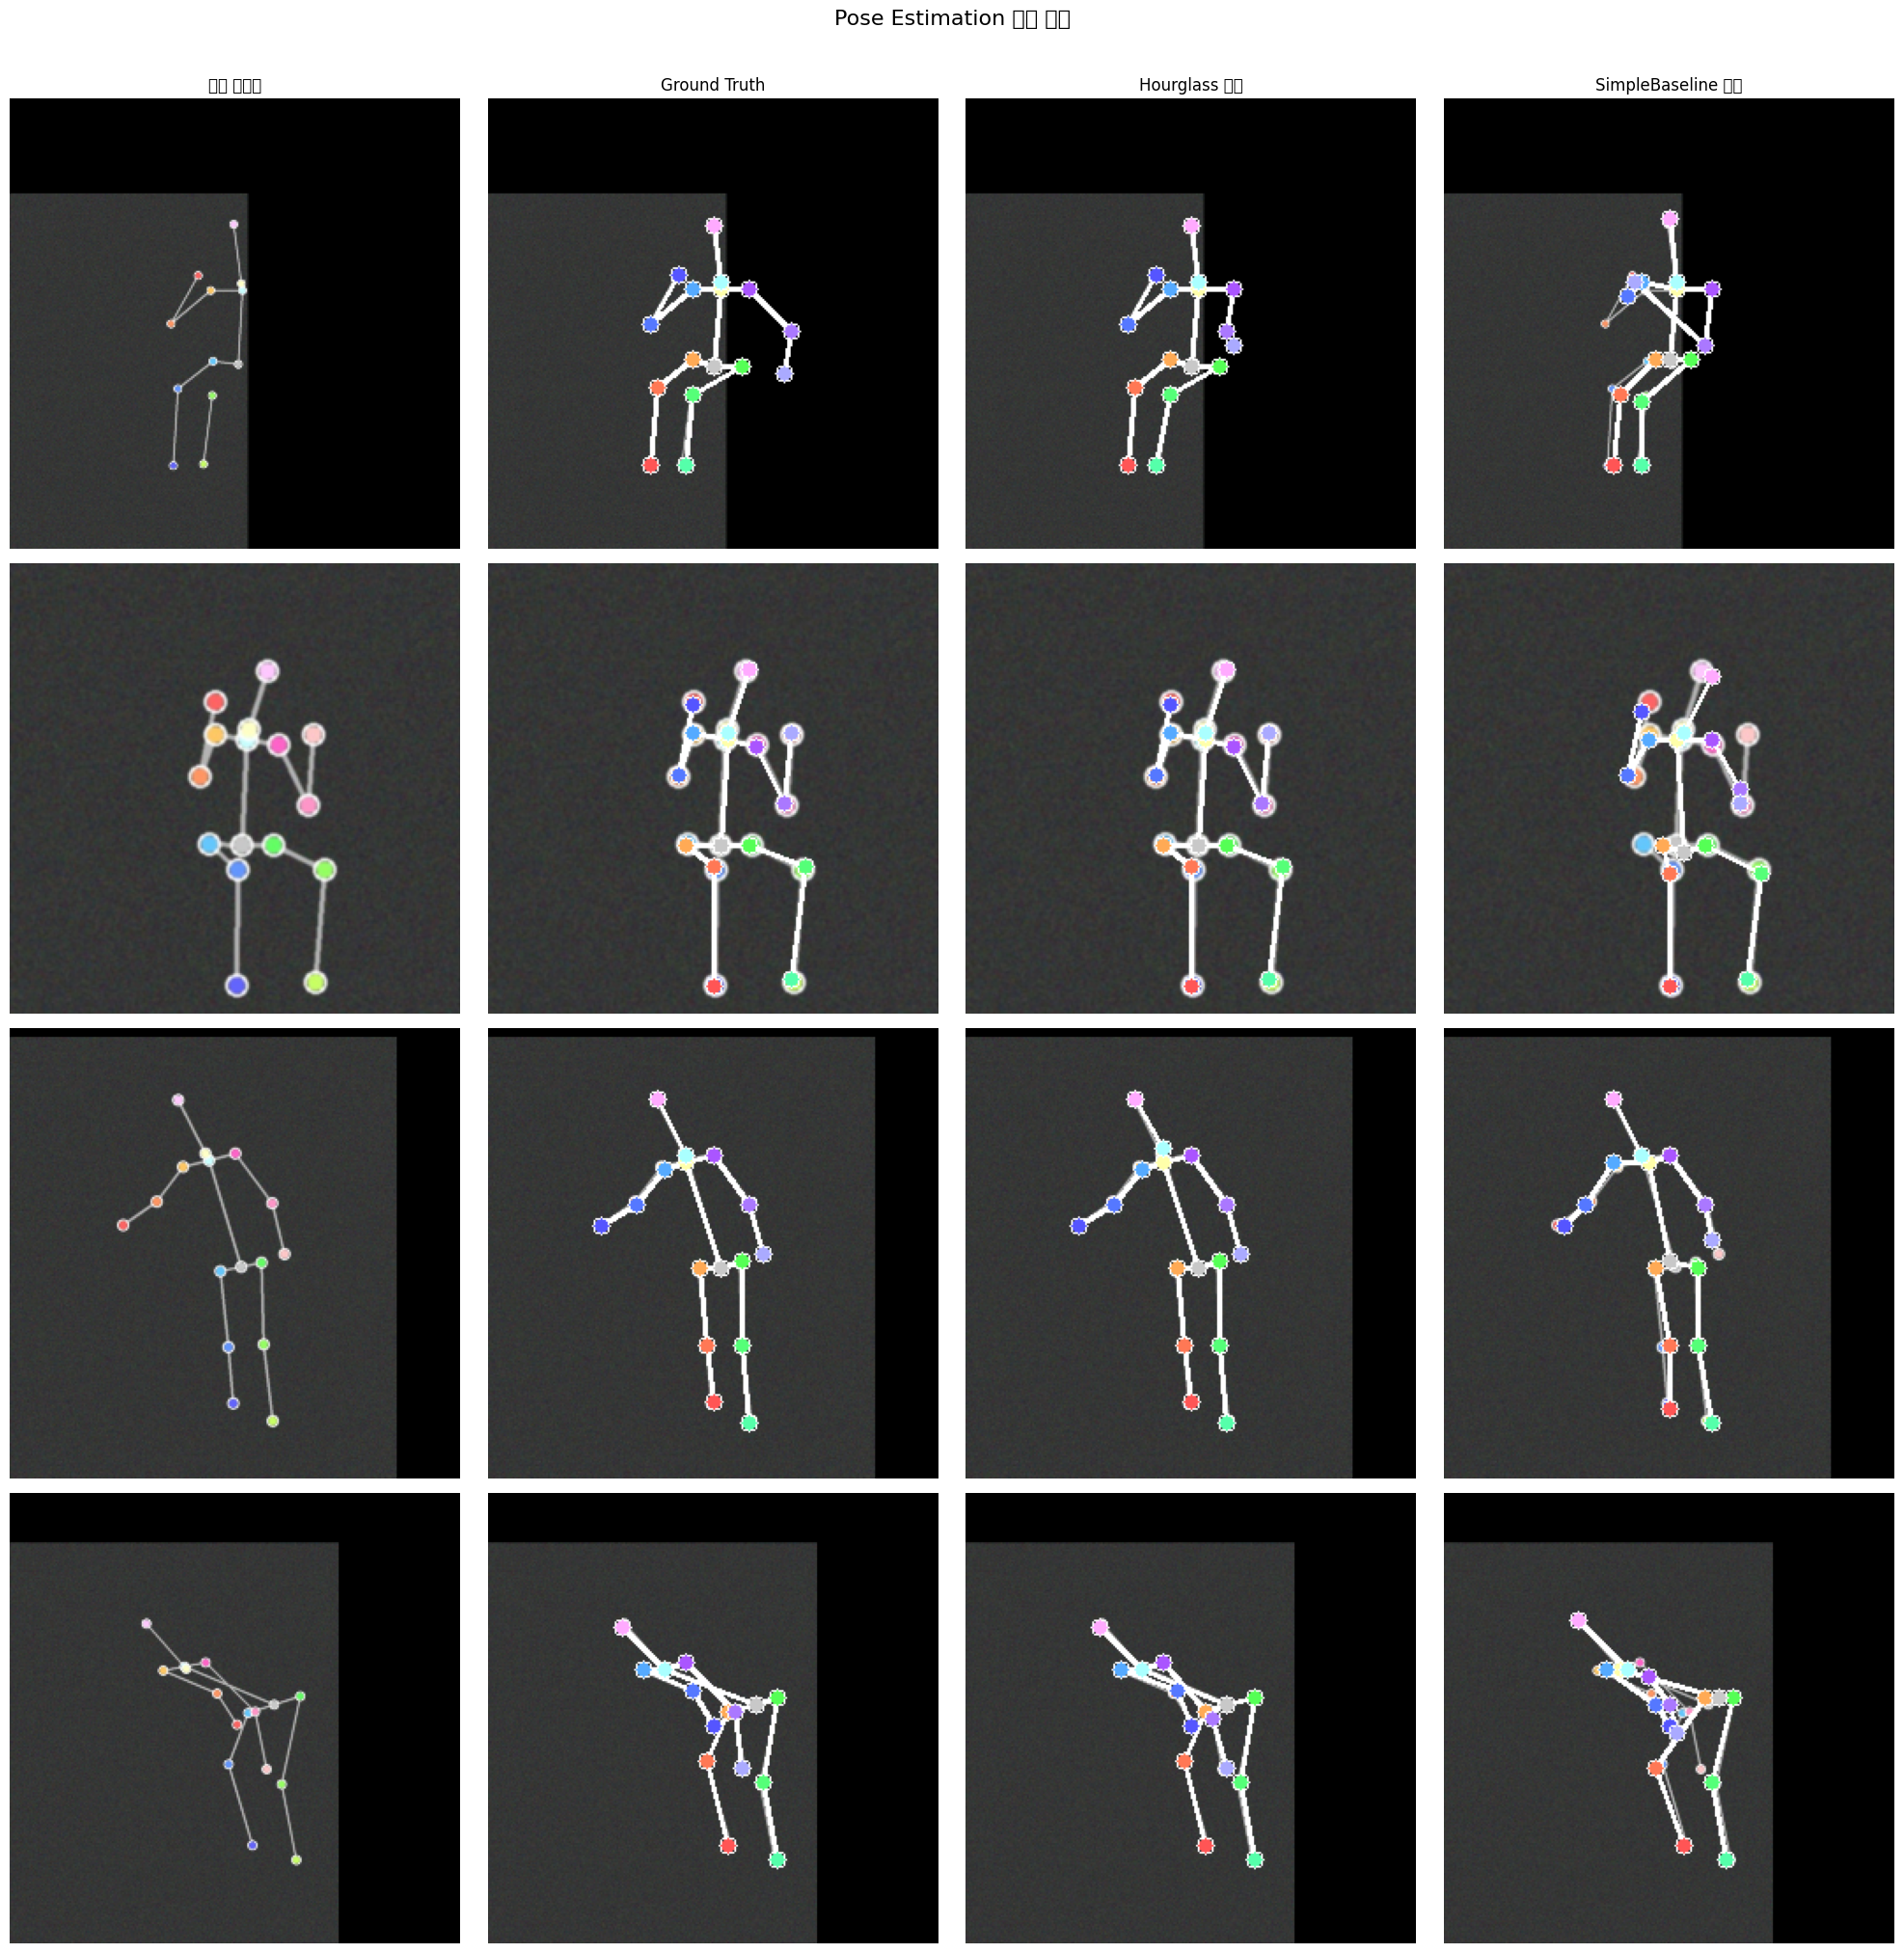

In [17]:
# Pose Estimation 시각화 비교 (Validation 샘플 4개)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

num_samples = min(4, len(val_dataset))
fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))

for i in range(num_samples):
    img_tensor, gt_heatmap, vis = val_dataset[i]
    
    img_display = inv_normalize(img_tensor).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display * 255, 0, 255).astype(np.uint8)
    
    gt_kps, gt_conf = heatmaps_to_keypoints(gt_heatmap.numpy(), IMAGE_SIZE)
    hg_kps, hg_conf, _ = get_predictions(hourglass_model, img_tensor, device, 'hourglass')
    sb_kps, sb_conf, _ = get_predictions(sb_model, img_tensor, device, 'simple')
    
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title("입력 이미지" if i == 0 else ""); axes[i, 0].axis('off')
    
    axes[i, 1].imshow(draw_pose(img_display, gt_kps, gt_conf, 0.01))
    axes[i, 1].set_title("Ground Truth" if i == 0 else ""); axes[i, 1].axis('off')
    
    axes[i, 2].imshow(draw_pose(img_display, hg_kps, hg_conf, 0.01))
    axes[i, 2].set_title("Hourglass 예측" if i == 0 else ""); axes[i, 2].axis('off')
    
    axes[i, 3].imshow(draw_pose(img_display, sb_kps, sb_conf, 0.01))
    axes[i, 3].set_title("SimpleBaseline 예측" if i == 0 else ""); axes[i, 3].axis('off')

plt.suptitle('Pose Estimation 결과 비교', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

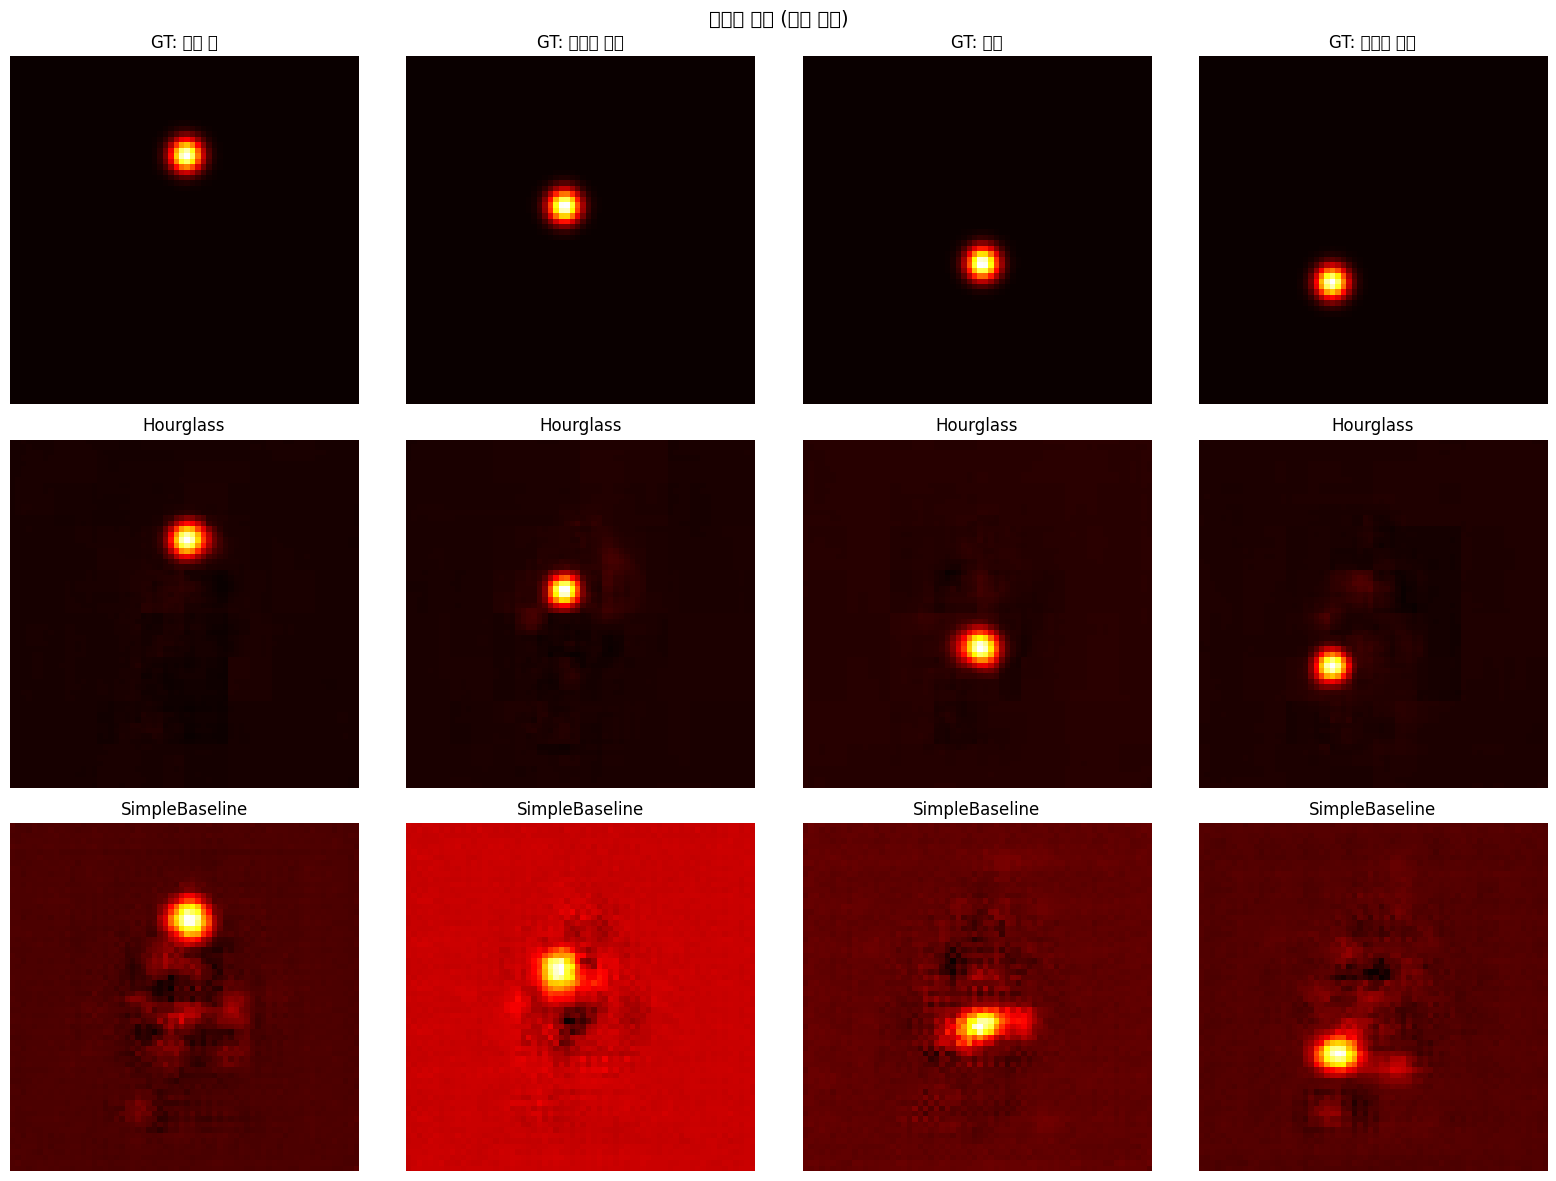

In [18]:
# 히트맵 시각화 비교
img_tensor, gt_heatmap, vis = val_dataset[0]
_, _, hg_hms = get_predictions(hourglass_model, img_tensor, device, 'hourglass')
_, _, sb_hms = get_predictions(sb_model, img_tensor, device, 'simple')

joint_indices = [9, 12, 6, 1]
joint_labels = ['머리 위', '오른쪽 어깨', '골반', '오른쪽 무릎']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for col, (j_idx, j_name) in enumerate(zip(joint_indices, joint_labels)):
    axes[0, col].imshow(gt_heatmap[j_idx].numpy(), cmap='hot')
    axes[0, col].set_title(f"GT: {j_name}"); axes[0, col].axis('off')
    
    axes[1, col].imshow(hg_hms[j_idx], cmap='hot')
    axes[1, col].set_title("Hourglass"); axes[1, col].axis('off')
    
    axes[2, col].imshow(sb_hms[j_idx], cmap='hot')
    axes[2, col].set_title("SimpleBaseline"); axes[2, col].axis('off')

plt.suptitle('히트맵 비교 (주요 관절)', fontsize=14)
plt.tight_layout(); plt.show()

## 정량적 비교

---

In [19]:
# 추론 시간 및 정량 비교
hg_total_time, hg_per_sample = measure_inference_time(hourglass_model, val_loader, device)
sb_total_time, sb_per_sample = measure_inference_time(sb_model, val_loader, device)

hg_params = sum(p.numel() for p in hourglass_model.parameters())
sb_params = sum(p.numel() for p in sb_model.parameters())

print("=" * 70)
print(f"{'항목':<25} {'Hourglass':>20} {'SimpleBaseline':>20}")
print("=" * 70)
print(f"{'총 파라미터 수':<25} {hg_params:>17,} {sb_params:>17,}")
print(f"{'파라미터 (M)':<25} {hg_params/1e6:>20.1f} {sb_params/1e6:>20.1f}")
print(f"{'최종 Train Loss':<25} {hg_history['train_loss'][-1]:>20.6f} {sb_history['train_loss'][-1]:>20.6f}")
print(f"{'최종 Val Loss':<25} {hg_history['val_loss'][-1]:>20.6f} {sb_history['val_loss'][-1]:>20.6f}")
print(f"{'최소 Val Loss':<25} {min(hg_history['val_loss']):>20.6f} {min(sb_history['val_loss']):>20.6f}")
print(f"{'추론 시간 (전체)':<25} {hg_total_time:>19.3f}s {sb_total_time:>19.3f}s")
print(f"{'추론 시간 (샘플당)':<25} {hg_per_sample*1000:>18.1f}ms {sb_per_sample*1000:>18.1f}ms")
print(f"{'Pre-trained backbone':<25} {'No':>20} {'Yes (ImageNet)':>20}")
print(f"{'Intermediate Supervision':<25} {'Yes (2 stacks)':>20} {'No':>20}")
print("=" * 70)

항목                                   Hourglass       SimpleBaseline
총 파라미터 수                         17,682,400        33,999,440
파라미터 (M)                                  17.7                 34.0
최종 Train Loss                         0.000615             0.000898
최종 Val Loss                           0.001118             0.001139
최소 Val Loss                           0.000890             0.001139
추론 시간 (전체)                              1.912s               1.206s
추론 시간 (샘플당)                             19.1ms               12.1ms
Pre-trained backbone                        No       Yes (ImageNet)
Intermediate Supervision        Yes (2 stacks)                   No


## 고찰 및 분석

---

### 1. 아키텍처 비교

| 특성 | Stacked Hourglass | SimpleBaseline |
|------|-------------------|----------------|
| **구조** | 재귀적 인코더-디코더 (양파 구조) | ResNet backbone + Deconv head |
| **핵심 아이디어** | 멀티스케일 특징 반복 정제 | 강력한 pre-trained backbone 활용 |
| **학습 전략** | Intermediate supervision (각 stack마다 loss) | 단일 출력 MSE loss |
| **Pre-training** | 없음 (from scratch) | ImageNet pre-trained |

### 2. 학습 특성 비교

- **수렴 속도**: SimpleBaseline이 pre-trained backbone 덕분에 초기부터 의미 있는 특징을 추출 → 더 빠르게 수렴
- **Hourglass**는 from scratch 학습 → 초반 loss 높고 수렴 느림
- 소규모 데이터에서는 pre-trained backbone 이점이 더 두드러짐

### 3. 모델 설계 철학
- **Hourglass**: "정교한 구조로 멀티스케일 특징을 재귀적으로 정제"
- **SimpleBaseline**: "충분히 좋은 backbone + 간단한 head = 효과적"

### 4. 한계 및 개선 방향
- 합성 이미지 사용으로 절대적 성능 비교에 한계
- 실제 MPII 전체 데이터셋으로 학습 시 차이가 더 명확해질 것
- 개선: data augmentation, PCKh 메트릭, learning rate warmup

# 5. 결론 및 회고

---

본 프로젝트에서는 MPII Human Pose Dataset 기반으로 **Stacked Hourglass Network**와 **SimpleBaseline** 두 모델을 구현·학습·비교하였습니다.

### 핵심 결과
1. **데이터 파이프라인**: MPII annotation 파싱, 이미지 크롭, 2D 가우시안 히트맵 생성, DataLoader 구성
2. **SimpleBaseline 구현**: ResNet50 backbone + 3 Deconv layers로 Hourglass 모델을 대체
3. **모델 비교**: loss 곡선, pose 시각화, 히트맵 비교, 정량 지표를 통한 체계적 비교 분석

In [20]:
# 환경 정보
import sys
print("=" * 40)
print("환경 정보")
print("=" * 40)
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"NumPy: {np.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"Device: {device}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print("=" * 40)

환경 정보
Python: 3.9.6 (default, Apr  7 2026, 02:38:40) 
[Clang 21.0.0 (clang-2100.0.123.102)]
PyTorch: 2.8.0
Torchvision: 0.23.0
NumPy: 2.0.2
OpenCV: 4.13.0
Device: mps
MPS available: True
